# Multi-LLM validation of inferred persona attributes

Inter-rater reliability across the model panel for the two LLM-inferred attributes (no ground truth):

- `financial_security_score` (1–5, ordinal) — all 500 personas
- `relationship_status` (Single/Dating, nominal) — single personas only (~243)

Inputs: `outputs/validation/preds_<tag>_<version>.jsonl` (one per rater × prompt version, produced by `src/validation/run_inference.py`) and `outputs/validation/validation_personas_500.csv`. Set `PROMPT_VERSION` in the first code cell; for a v1-vs-v2 pilot comparison use `src/validation/pilot_report.py` instead.

Statistics: Krippendorff's alpha (ordinal / nominal), pairwise Cohen's kappa (quadratic-weighted for the score), consensus labels (median / majority vote). Works on however many raters have finished — rerun after each model completes.

In [1]:
import glob
import json

import krippendorff
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import cohen_kappa_score

PROMPT_VERSION = "v2"  # which prompt set's predictions to analyse (see src/validation/inference_prompts.py)

personas = pd.read_csv("outputs/validation/validation_personas_500.csv")

frames = []
for path in sorted(glob.glob(f"outputs/validation/preds_*_{PROMPT_VERSION}.jsonl")):
    recs = {}
    with open(path, encoding="utf-8") as f:
        for line in f:
            if line.strip():
                r = json.loads(line)
                recs[r["persona_id"]] = r  # last line per persona wins (resume re-runs)
    frames.append(pd.DataFrame(recs.values()))
preds = pd.concat(frames, ignore_index=True)
preds_ok = preds[preds["error"].isna()]
models = sorted(preds["model_tag"].unique())
print(f"prompt version: {PROMPT_VERSION}, raters: {models}")

coverage = (preds.assign(ok=preds["error"].isna())
            .groupby("model_tag")["ok"].agg(attempted="size", succeeded="sum"))
coverage["errors"] = coverage["attempted"] - coverage["succeeded"]
coverage

prompt version: v2, raters: ['nemotron-120b']


,attempted,succeeded,errors
model_tag,,,
nemotron-120b,3,3,0


## Financial security score (ordinal, all personas)

In [2]:
fin = preds_ok.pivot(index="persona_id", columns="model_tag", values="fin_score")
print(f"personas with at least one rating: {len(fin)}")
print(f"personas rated by all {len(models)} raters: {len(fin.dropna())}")

if len(models) >= 2:
    # Krippendorff's alpha: reliability_data is raters x units, NaN = missing
    alpha_ord = krippendorff.alpha(
        reliability_data=fin[models].T.values.astype(float),
        level_of_measurement="ordinal",
    )
    print(f"\nKrippendorff's alpha (ordinal): {alpha_ord:.3f}")
    print("rule of thumb: >=0.80 reliable, 0.667-0.80 tentative (Krippendorff 2004)")
else:
    print("\nKrippendorff's alpha needs >=2 raters — run more models first")

print("\nPer-rater mean score (severity bias):")
print(fin[models].mean().round(2).to_string())

personas with at least one rating: 3
personas rated by all 1 raters: 3

Krippendorff's alpha needs >=2 raters — run more models first

Per-rater mean score (severity bias):
model_tag
nemotron-120b    2.0


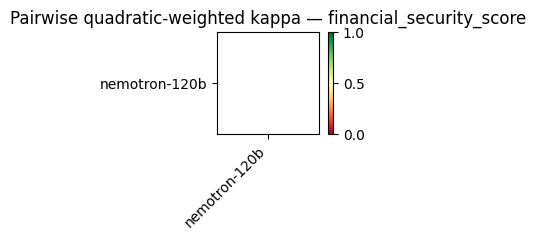

In [3]:
# Pairwise quadratic-weighted Cohen's kappa heatmap
k = len(models)
kappa = np.full((k, k), np.nan)
for i, a in enumerate(models):
    for j, b in enumerate(models):
        pair = fin[[a, b]].dropna()
        if i != j and len(pair):
            kappa[i, j] = cohen_kappa_score(pair[a], pair[b], weights="quadratic")

fig, ax = plt.subplots(figsize=(1.2 * k + 2, 1.0 * k + 1.5))
im = ax.imshow(kappa, cmap="RdYlGn", vmin=0, vmax=1)
ax.set_xticks(range(k), models, rotation=45, ha="right")
ax.set_yticks(range(k), models)
ax.set_title("Pairwise quadratic-weighted kappa — financial_security_score")
for i in range(k):
    for j in range(k):
        if i != j:
            ax.text(j, i, f"{kappa[i, j]:.2f}", ha="center", va="center", fontsize=9)
fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

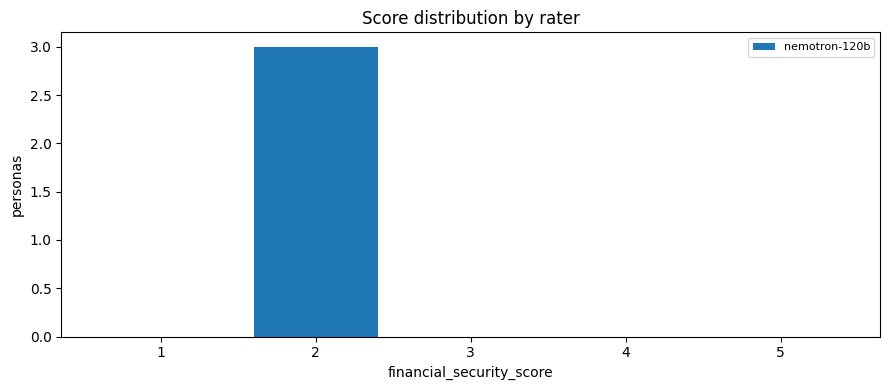

In [4]:
# Score distribution per rater
scores = [1, 2, 3, 4, 5]
x = np.arange(len(scores))
w = 0.8 / len(models)
fig, ax = plt.subplots(figsize=(9, 4))
for m_idx, m in enumerate(models):
    counts = fin[m].value_counts().reindex(scores, fill_value=0)
    ax.bar(x + (m_idx - (len(models) - 1) / 2) * w, counts, w, label=m)
ax.set_xticks(x, scores)
ax.set_xlabel("financial_security_score")
ax.set_ylabel("personas")
ax.set_title("Score distribution by rater")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

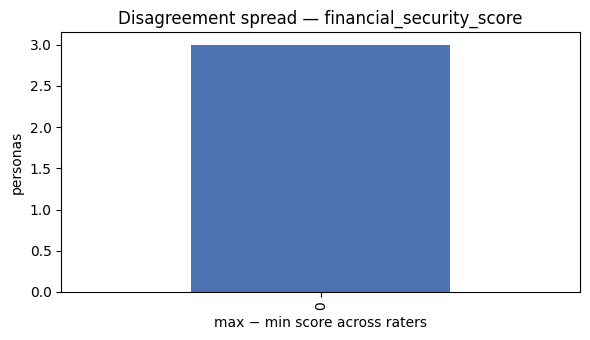

fin_spread
0    3
Name: count, dtype: int64

In [5]:
# Consensus (median) and disagreement spread
fin_stats = pd.DataFrame({
    "fin_consensus_median": fin.median(axis=1),
    "fin_spread": fin.max(axis=1) - fin.min(axis=1),
    "n_raters_fin": fin.notna().sum(axis=1),
})

fig, ax = plt.subplots(figsize=(6, 3.5))
fin_stats["fin_spread"].value_counts().sort_index().plot.bar(ax=ax, color="#4c72b0")
ax.set_xlabel("max − min score across raters")
ax.set_ylabel("personas")
ax.set_title("Disagreement spread — financial_security_score")
plt.tight_layout()
plt.show()

fin_stats["fin_spread"].value_counts().sort_index()

In [6]:
# Worst disagreements: all raters' scores and reasoning side by side
worst_ids = fin_stats.sort_values("fin_spread", ascending=False).head(5).index
for pid in worst_ids:
    p = personas.set_index("persona_id").loc[pid]
    print("=" * 100)
    print(f"{pid}: {p['age']}yo {p['gender']}, {p['education']}, "
          f"{p['occupation']} ({p['industry']}), {p['planning_area']}")
    rows = preds_ok[preds_ok["persona_id"] == pid].sort_values("fin_score")
    for _, r in rows.iterrows():
        print(f"  [{r['fin_score']}] {r['model_tag']}: {r['fin_reasoning']}")

V001: 39yo female, University, Homemaker (nan), Choa Chu Kang
  [2] nemotron-120b: As a full‑time homemaker with no personal income, her occupation signals limited current earnings (cue 1). However, she holds a university degree, indicating the potential for higher earnings if she re‑enters the workforce or launches a side‑hustle (cue 2). Living in the mature HDB town of Choa Chu Kang suggests moderate housing costs, but without a spouse’s income details we must rely on her own financial situation, which points to a lower‑middle security level.
V002: 22yo male, University, Associate Professional or Technician (Manufacturing), Kallang
  [2] nemotron-120b: At 22 with a university degree, Jiun Ming is likely in an entry‑level Associate Professional/Technician role in manufacturing, which typically offers a starting salary just above the lower‑middle range. His residence in the mature HDB town of Kallang suggests modest housing costs but limited asset accumulation at this early career stag

## Relationship status (nominal, single personas only)

In [7]:
single_ids = personas.loc[personas["rel_status"] == "single", "persona_id"]
rel = (preds_ok[preds_ok["persona_id"].isin(single_ids)]
       .pivot(index="persona_id", columns="model_tag", values="rel_status"))
print(f"single personas rated: {len(rel)}")

rel_num = rel.replace({"Single": 0, "Dating": 1})
try:
    alpha_nom = krippendorff.alpha(
        reliability_data=rel_num[models].T.values.astype(float),
        level_of_measurement="nominal",
    )
    print(f"Krippendorff's alpha (nominal): {alpha_nom:.3f}")
except ValueError as e:
    # <2 raters, or no variation yet (e.g. every rating "Single" in a smoke run)
    print(f"Krippendorff's alpha not computable yet: {e}")

print("\nPer-rater % judged Dating:")
print((rel_num[models].mean() * 100).round(1).to_string())

kappa_rel = np.full((len(models), len(models)), np.nan)
for i, a in enumerate(models):
    for j, b in enumerate(models):
        pair = rel[[a, b]].dropna()
        if i != j and len(pair) and pair[a].nunique() > 1 and pair[b].nunique() > 1:
            kappa_rel[i, j] = cohen_kappa_score(pair[a], pair[b])
pd.DataFrame(kappa_rel, index=models, columns=models).round(2)

single personas rated: 1
Krippendorff's alpha not computable yet: There has to be more than one value in the domain.

Per-rater % judged Dating:
model_tag
nemotron-120b    0.0


,nemotron-120b
nemotron-120b,NaN


In [8]:
# Majority-vote consensus; ties broken by the gpt-4.1 anchor (flagged)
ANCHOR = "gpt-4.1"

def rel_consensus(row):
    votes = row.dropna()
    counts = votes.value_counts()
    if len(counts) == 1:
        return pd.Series({"rel_consensus": counts.index[0],
                          "rel_unanimous": True, "rel_tie": False})
    if counts.iloc[0] > counts.iloc[1]:
        return pd.Series({"rel_consensus": counts.index[0],
                          "rel_unanimous": False, "rel_tie": False})
    winner = votes.get(ANCHOR, counts.index[0])  # tie -> anchor's vote
    return pd.Series({"rel_consensus": winner,
                      "rel_unanimous": False, "rel_tie": True})

rel_stats = rel.apply(rel_consensus, axis=1)
print(rel_stats[["rel_unanimous", "rel_tie"]].sum().to_string())
print("\nConsensus distribution:")
print(rel_stats["rel_consensus"].value_counts().to_string())

# Disagreement examples with reasoning
split_ids = rel_stats[~rel_stats["rel_unanimous"]].index[:5]
for pid in split_ids:
    print("=" * 100)
    rows = preds_ok[preds_ok["persona_id"] == pid]
    for _, r in rows.iterrows():
        print(f"  [{r['rel_status']}] {r['model_tag']}: {r['rel_reasoning']}")

rel_unanimous    1
rel_tie          0

Consensus distribution:
rel_consensus
Single    1


In [9]:
# Export consensus labels + per-persona agreement metrics
consensus = fin_stats.join(rel_stats, how="left")
consensus.index.name = "persona_id"
consensus.to_csv("outputs/validation/consensus_labels.csv")
print(f"Saved {len(consensus)} rows to outputs/validation/consensus_labels.csv")
consensus.head(10)

Saved 3 rows to outputs/validation/consensus_labels.csv


,fin_consensus_median,fin_spread,n_raters_fin,rel_consensus,rel_unanimous,rel_tie
persona_id,,,,,,
V001,2.0,0,1,NaN,NaN,NaN
V002,2.0,0,1,Single,True,False
V003,2.0,0,1,NaN,NaN,NaN
